# 📊 PROJET : SALES FORECASTING - AMAZON DATASET

**Résumé du Projet** :  
Les prévisions de ventes sont cruciales pour l'optimisation des stocks, la planification des capacités et la gestion des flux de trésorerie. Ce notebook utilise un dataset de ventes Amazon pour construire, évaluer et comparer quatre modèles de séries temporelles. L'objectif est d'identifier le modèle le plus performant pour prédire les ventes futures sur 12 mois.

**Choix des Modèles** :
- **SARIMA** : Modèle statistique classique robuste pour capturer la composante autorégressive et la saisonnalité explicite.
- **Holt-Winters (Lissage Exponentiel Triple)** : Décompose la série en niveau, tendance et saisonnalité — idéal pour des séries avec croissance et cycles annuels marqués.
- **LSTM** : Réseau de neurones récurrents, capable d'apprendre des dépendances temporelles complexes et non linéaires.
- **XGBoost** : Algorithme d'arbres de décision boostés, particulièrement performant avec du feature engineering manuel (lags, rolling stats).

**Dataset** : Amazon Sales Dataset — 3 203 commandes, janvier 2011 à décembre 2014.


## 1. Importation des Bibliothèques
**Objectif** : Importer toutes les bibliothèques nécessaires pour l'analyse, la modélisation et la visualisation.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import random
import os

# Paramètres du projet
SEED = 42
SPLIT_RATIO = 0.8
SEQUENCE_LENGTH = 12

# Libraries pour l'analyse temporelle
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Libraries pour le deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Libraries pour XGBoost et Interprétation
from xgboost import XGBRegressor
import shap

# Set all seeds AFTER all imports
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

def plot_predictions(train_idx, train_val, test_idx, test_val, pred_idx, pred_val, title, color, filename=None):
    plt.figure(figsize=(12, 6))
    plt.plot(train_idx, train_val, label='Entraînement', color='blue')
    plt.plot(test_idx, test_val, label='Réel', color='green')
    plt.plot(pred_idx, pred_val, label=f'{title} Prédictions', color=color, linestyle='--')
    plt.title(f'Prévisions {title} vs Données Réelles')
    plt.xlabel('Date')
    plt.ylabel('Ventes ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    if filename:
        plt.savefig(filename)
    plt.show()

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Toutes les bibliothèques ont été importées avec succès")


✅ Toutes les bibliothèques ont été importées avec succès


## 2. Chargement et Exploration des Données
**Objectif** : Charger les données complètes et comprendre leur structure, qualité et caractéristiques.

In [56]:
# FIX 2a: Define data path as a constant for easy reconfiguration
DATA_PATH = 'Amazon 2_Raw.xlsx'

print("🔍 CHARGEMENT ET EXPLORATION DES DONNÉES")

import os as _os
if not _os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset introuvable : '{DATA_PATH}'. Veuillez placer le fichier dans le même répertoire que ce notebook.")

df = pd.read_excel(DATA_PATH)

# Conversion des dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("📊 Aperçu des données :")
display(df.head())
print(f"\n📈 Dimensions du dataset : {df.shape}")
print(f"\n📅 Période couverte : {df['Order Date'].min()} à {df['Order Date'].max()}")

print("\n🔍 INFORMATIONS SUR LE DATASET :")
df.info()
print("\n📊 STATISTIQUES DESCRIPTIVES :")
display(df[['Sales', 'Quantity', 'Profit']].describe())

print("\n🔍 VALEURS MANQUANTES :")
print(df.isnull().sum())

print(f"\n🔍 NOMBRE DE DOUBLONS : {df.duplicated().sum()}")


🔍 CHARGEMENT ET EXPLORATION DES DONNÉES
📊 Aperçu des données :


,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,Newell 322,7.280,4,1.9656
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825



📈 Dimensions du dataset : (3203, 10)

📅 Période couverte : 2011-01-07 00:00:00 à 2014-12-31 00:00:00

🔍 INFORMATIONS SUR LE DATASET :
<class 'pandas.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      3203 non-null   str           
 1   Order Date    3203 non-null   datetime64[us]
 2   Ship Date     3203 non-null   datetime64[us]
 3   EmailID       3203 non-null   str           
 4   Geography     3203 non-null   str           
 5   Category      3203 non-null   str           
 6   Product Name  3203 non-null   str           
 7   Sales         3203 non-null   float64       
 8   Quantity      3203 non-null   int64         
 9   Profit        3203 non-null   float64       
dtypes: datetime64[us](2), float64(2), int64(1), str(5)
memory usage: 605.8 KB

📊 STATISTIQUES DESCRIPTIVES :


,Sales,Quantity,Profit
count,3203.000000,3203.000000,3203.000000
mean,226.493233,3.828910,33.849032
std,524.876877,2.260947,174.109081
min,0.990000,1.000000,-3399.980000
25%,19.440000,2.000000,3.852000
50%,60.840000,3.000000,11.166400
75%,215.809000,5.000000,33.000400
max,13999.960000,14.000000,6719.980800



🔍 VALEURS MANQUANTES :
Order ID        0
Order Date      0
Ship Date       0
EmailID         0
Geography       0
Category        0
Product Name    0
Sales           0
Quantity        0
Profit          0
dtype: int64

🔍 NOMBRE DE DOUBLONS : 0


**Résultats** : Le dataset contient 3203 entrées et 10 colonnes. La période couverte va du 2011-01-07 au 2014-12-31. Il n'y a pas de valeurs manquantes ni de doublons. Les statistiques descriptives montrent une large dispersion des ventes et des profits, avec une marge de profit moyenne de 33.85%, mais aussi des profits négatifs (minimum -3399.98).

## 3. Feature Engineering
**Objectif** : Créer de nouvelles variables temporelles et géographiques pour enrichir l'analyse.

In [57]:
print("\n🔧 FEATURE ENGINEERING")

# Extraction des composantes temporelles
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['DayOfWeek'] = df['Order Date'].dt.dayofweek
df['DayOfYear'] = df['Order Date'].dt.dayofyear
df['WeekOfYear'] = df['Order Date'].dt.isocalendar().week

# Création d'indicateurs saisonniers
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
df['IsMonthStart'] = df['Order Date'].dt.is_month_start.astype(int)
df['IsMonthEnd'] = df['Order Date'].dt.is_month_end.astype(int)

# FIX 2b: Safe Geography split – cap at 2 splits to always get 3 columns max
# and fill missing values to avoid misalignment
geo_split = df['Geography'].str.split(',', n=2, expand=True)
geo_split.columns = ['Country', 'City', 'State'][:len(geo_split.columns)]
for col in ['Country', 'City', 'State']:
    if col not in geo_split.columns:
        geo_split[col] = None
df[['Country', 'City', 'State']] = geo_split[['Country', 'City', 'State']]

# Calcul du prix unitaire et de la marge
df['Unit_Price'] = df['Sales'] / df['Quantity']
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

# Temps de livraison
df['Delivery_Time'] = (df['Ship Date'] - df['Order Date']).dt.days

print("✅ Features temporelles et géographiques créées avec succès")
print(df[['Order Date', 'Year', 'Month', 'Quarter', 'DayOfWeek', 'State', 'Unit_Price', 'Delivery_Time']].head())



🔧 FEATURE ENGINEERING
✅ Features temporelles et géographiques créées avec succès
  Order Date  Year  Month  Quarter  DayOfWeek       State  Unit_Price  \
0 2013-06-13  2013      6        2          3  California       7.310   
1 2011-06-09  2011      6        2          3  California       6.980   
2 2011-06-09  2011      6        2          3  California       1.820   
3 2011-06-09  2011      6        2          3  California     226.788   
4 2011-06-09  2011      6        2          3  California       6.168   

   Delivery_Time  
0              4  
1              5  
2              5  
3              5  
4              5  


**Interprétation** : Les nouvelles variables extraites (Année, Mois, Trimestre, Jour de la semaine, etc.) et créées (Prix unitaire, Marge de profit, Temps de livraison) sont maintenant disponibles dans le dataframe. Elles permettront d'analyser les patterns temporels et géographiques, ainsi que des indicateurs de performance comme la marge et le temps de livraison.

In [58]:
print("\n📈 AGRÉGATION TEMPORELLE DES DONNÉES")

# Agrégation des données par date
daily_sales = df.groupby('Order Date').agg({
    'Sales': 'sum',
    'Quantity': 'sum',
    'Profit': 'sum',
    'Order Date': 'count'
}).rename(columns={'Order Date': 'Order_Count'})

# Rééchantillonnage pour avoir des données mensuelles et trimestrielles
monthly_sales = daily_sales.resample('ME').sum()
quarterly_sales = daily_sales.resample('QE').sum()

print(f"📊 Ventes quotidiennes : {len(daily_sales)} jours")
print(f"📊 Ventes mensuelles : {len(monthly_sales)} mois")
print(f"📊 Ventes trimestrielles : {len(quarterly_sales)} trimestres")

# Aperçu des données mensuelles
print("\n📅 APERÇU DES VENTES MENSUELLES :")
print(monthly_sales.head())

# Statistiques des ventes mensuelles
print("\n📊 STATISTIQUES DES VENTES MENSUELLES :")
print(monthly_sales[['Sales', 'Quantity', 'Profit']].describe())


📈 AGRÉGATION TEMPORELLE DES DONNÉES
📊 Ventes quotidiennes : 845 jours
📊 Ventes mensuelles : 48 mois
📊 Ventes trimestrielles : 16 trimestres

📅 APERÇU DES VENTES MENSUELLES :
                Sales  Quantity     Profit  Order_Count
Order Date                                             
2011-01-31   2648.057        62    20.9733           15
2011-02-28   1348.622        49   228.8282           17
2011-03-31  11008.898       150  1534.2273           44
2011-04-30   9343.487       179  1629.4545           48
2011-05-31   6570.438       141   873.5640           33

📊 STATISTIQUES DES VENTES MENSUELLES :
              Sales    Quantity       Profit
count     48.000000   48.000000    48.000000
mean   15113.704677  255.500000  2258.717685
std     8318.964550  145.524875  1848.123997
min     1348.622000   49.000000 -1867.750200
25%     9557.938250  145.500000  1173.948475
50%    13573.577500  233.500000  1775.131350
75%    21619.142750  337.000000  3251.708325
max    32617.340000  634.000000  

## 4. Agrégation Temporelle des Données
**Objectif** : Préparer les données pour l'analyse des séries temporelles en agrégeant par différentes périodes.

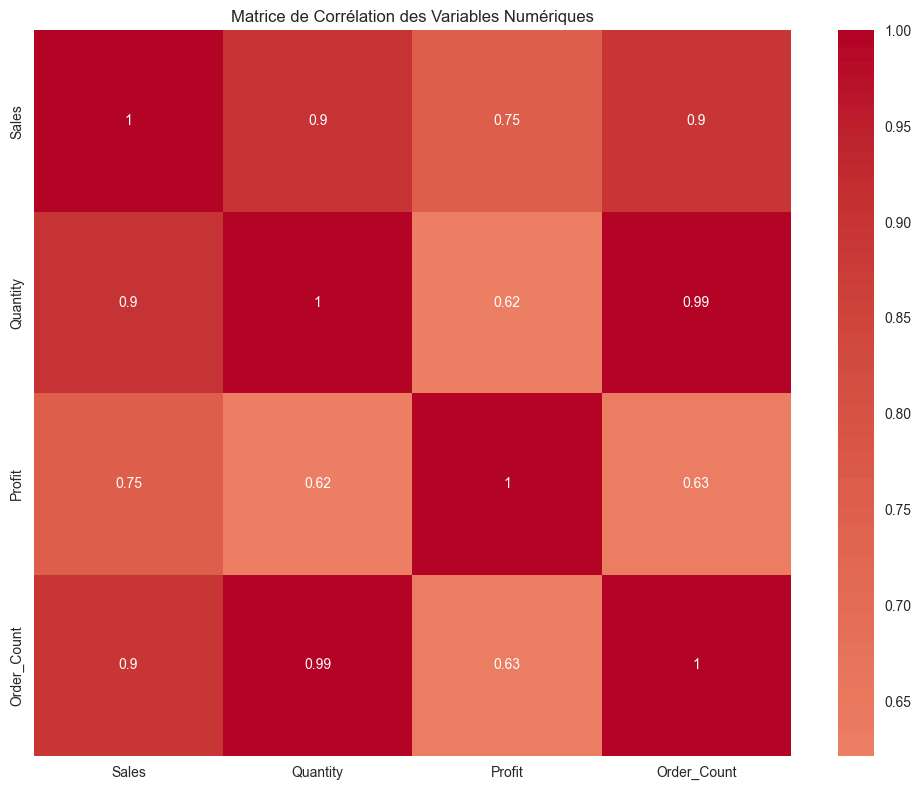

In [59]:
# Matrice de corrélation
corr_matrix = monthly_sales[['Sales', 'Quantity', 'Profit', 'Order_Count']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de Corrélation des Variables Numériques')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

**Résultats** : Agrégation réussie des données avec statistiques descriptives pour chaque période.

## 5. Visualisation de l'Évolution Temporelle
**Objectif** : Visualiser l'évolution des ventes dans le temps et identifier les patterns visuels.


📊 VISUALISATION DE L'ÉVOLUTION TEMPORELLE


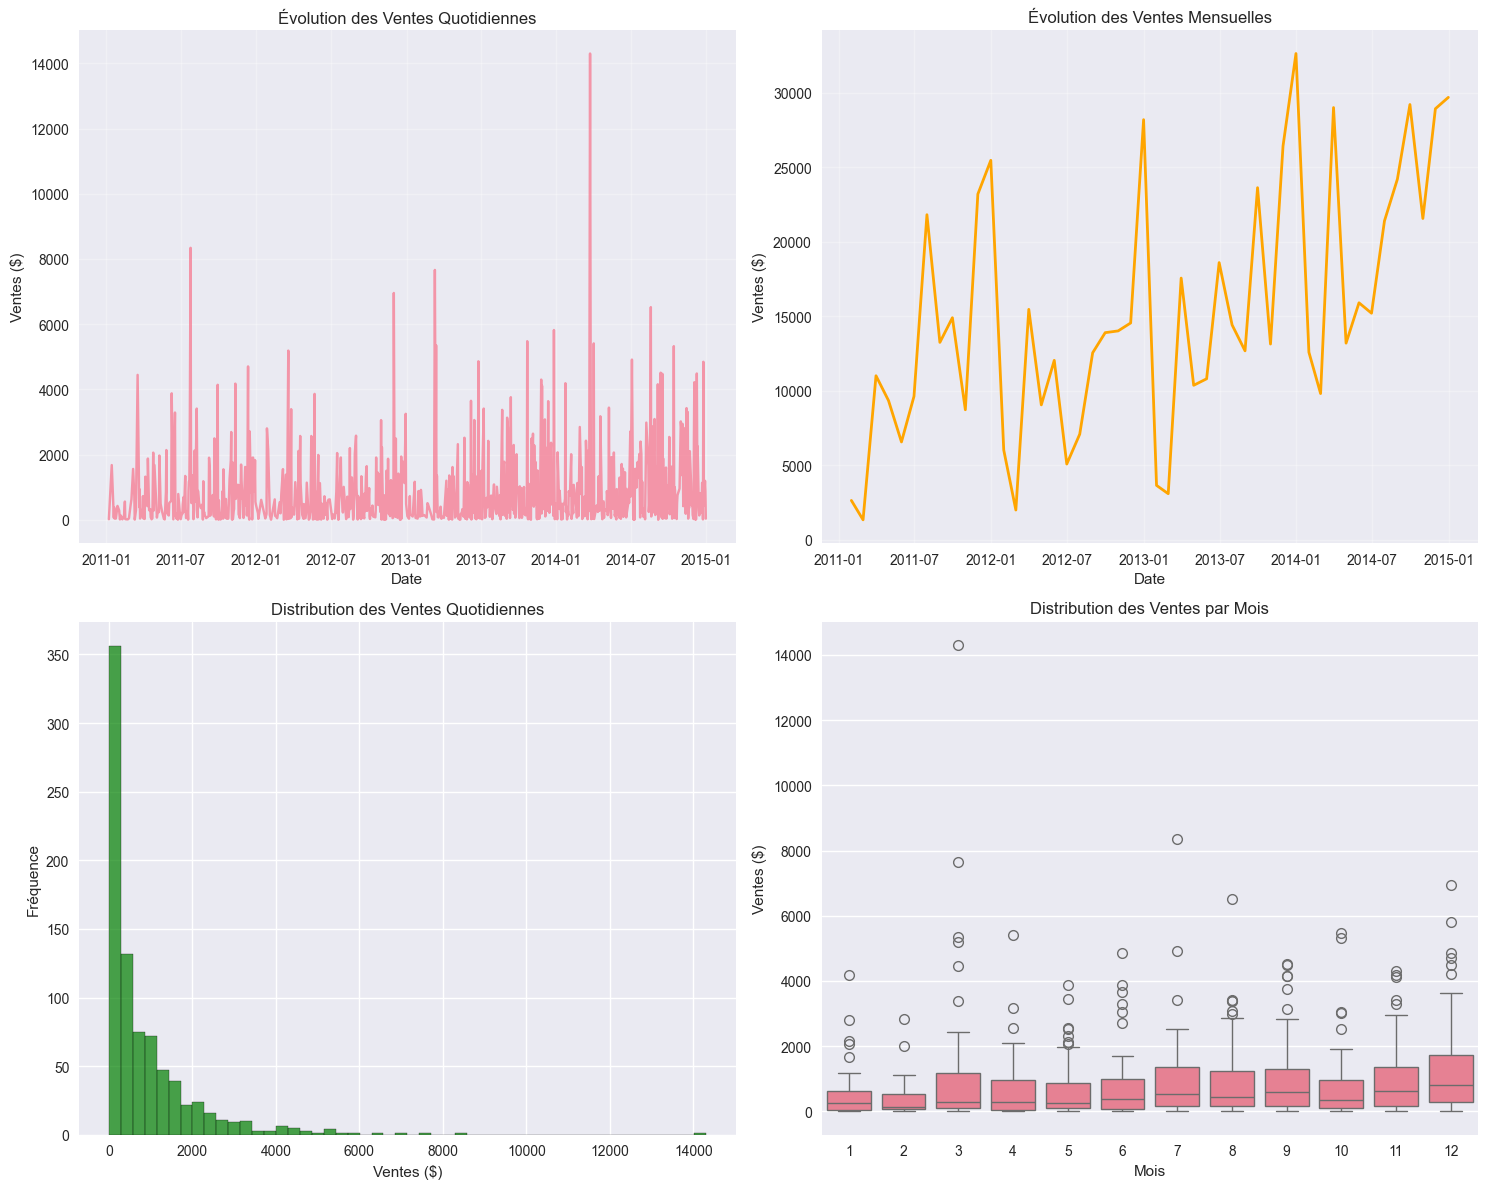

In [60]:
print("\n📊 VISUALISATION DE L'ÉVOLUTION TEMPORELLE")

# Visualisation de la série temporelle des ventes
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Ventes quotidiennes
axes[0, 0].plot(daily_sales.index, daily_sales['Sales'], alpha=0.7)
axes[0, 0].set_title('Évolution des Ventes Quotidiennes')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Ventes ($)')
axes[0, 0].grid(True, alpha=0.3)

# Ventes mensuelles
axes[0, 1].plot(monthly_sales.index, monthly_sales['Sales'], color='orange', linewidth=2)
axes[0, 1].set_title('Évolution des Ventes Mensuelles')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Ventes ($)')
axes[0, 1].grid(True, alpha=0.3)

# Distribution des ventes quotidiennes
axes[1, 0].hist(daily_sales['Sales'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1, 0].set_title('Distribution des Ventes Quotidiennes')
axes[1, 0].set_xlabel('Ventes ($)')
axes[1, 0].set_ylabel('Fréquence')

# Boxplot des ventes par mois
monthly_data = daily_sales.copy()
monthly_data['Month'] = monthly_data.index.month
sns.boxplot(data=monthly_data, x='Month', y='Sales', ax=axes[1, 1])
axes[1, 1].set_title('Distribution des Ventes par Mois')
axes[1, 1].set_xlabel('Mois')
axes[1, 1].set_ylabel('Ventes ($)')

plt.tight_layout()
plt.show()

**Interprétation** : Les graphiques montrent une tendance générale à la hausse des ventes au fil du temps, particulièrement visible sur la courbe des ventes mensuelles. On observe également une forte saisonnalité avec des pics de ventes, souvent en fin d'année. La distribution des ventes quotidiennes est asymétrique, indiquant la présence de valeurs extrêmes. Le boxplot par mois confirme une variation significative des ventes selon les mois, suggérant une saisonnalité marquée.

## 6. Analyse de Croissance et Saisonnalité
**Objectif** : Analyser la croissance des ventes et identifier les patterns saisonniers.


📈 ANALYSE DE CROISSANCE ET SAISONNALITÉ


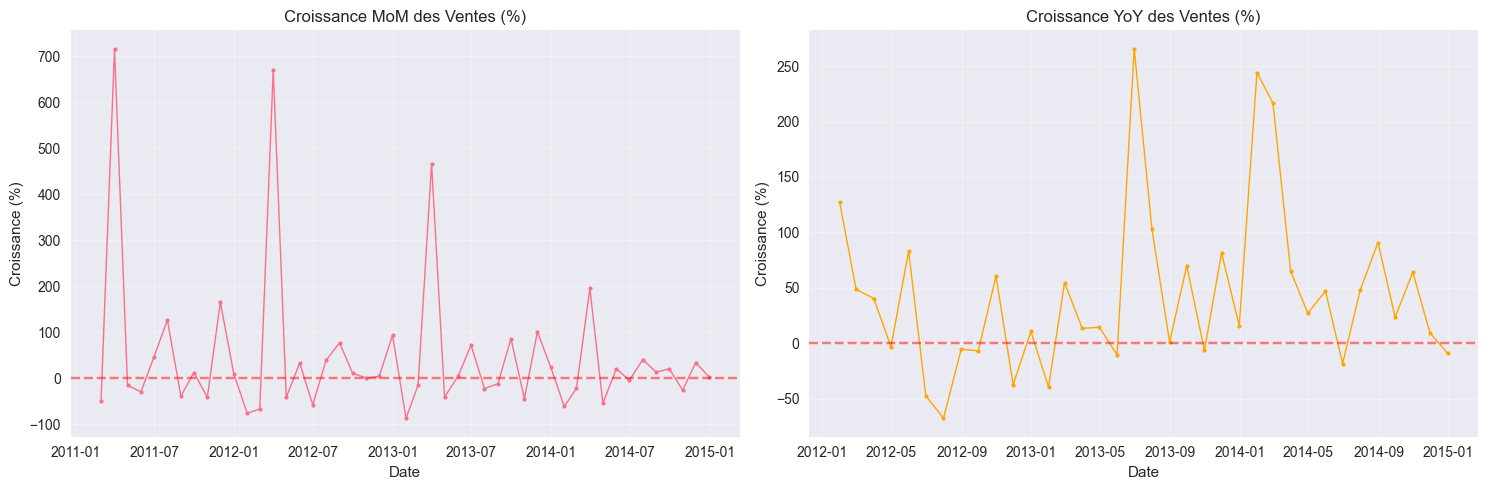

📊 Croissance MoM moyenne : 48.51%
📊 Croissance YoY moyenne : 43.82%


In [61]:
print("\n📈 ANALYSE DE CROISSANCE ET SAISONNALITÉ")

# Analyse de croissance MoM (Month over Month) et YoY (Year over Year)
monthly_growth = monthly_sales['Sales'].pct_change() * 100
yearly_growth = monthly_sales['Sales'].pct_change(12) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Croissance MoM
axes[0].plot(monthly_growth.index, monthly_growth, marker='o', linewidth=1, markersize=3)
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0].set_title('Croissance MoM des Ventes (%)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Croissance (%)')
axes[0].grid(True, alpha=0.3)

# Croissance YoY
axes[1].plot(yearly_growth.index, yearly_growth, marker='o', color='orange', linewidth=1, markersize=3)
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1].set_title('Croissance YoY des Ventes (%)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Croissance (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Affichage des statistiques de croissance
print(f"📊 Croissance MoM moyenne : {monthly_growth.mean():.2f}%")
print(f"📊 Croissance YoY moyenne : {yearly_growth.mean():.2f}%")

**Interprétation** : Les graphiques de croissance MoM et YoY montrent une forte variabilité. La croissance MoM présente des fluctuations importantes, reflétant la saisonnalité et d'autres facteurs à court terme. La croissance YoY semble un peu plus stable but montre également des variations, indiquant une croissance annuelle non linéaire. La croissance moyenne MoM de 48.51% et YoY de 43.82% (bien que ces moyennes incluent des valeurs négatives en raison des fluctuations) suggèrent une expansion globale de l'activité sur la période analysée.

## 7. Décomposition de la Série Temporelle
**Objectif** : Décomposer la série temporelle en ses composantes : tendance, saisonnalité et résidus.


🔍 DÉCOMPOSITION DE LA SÉRIE TEMPORELLE


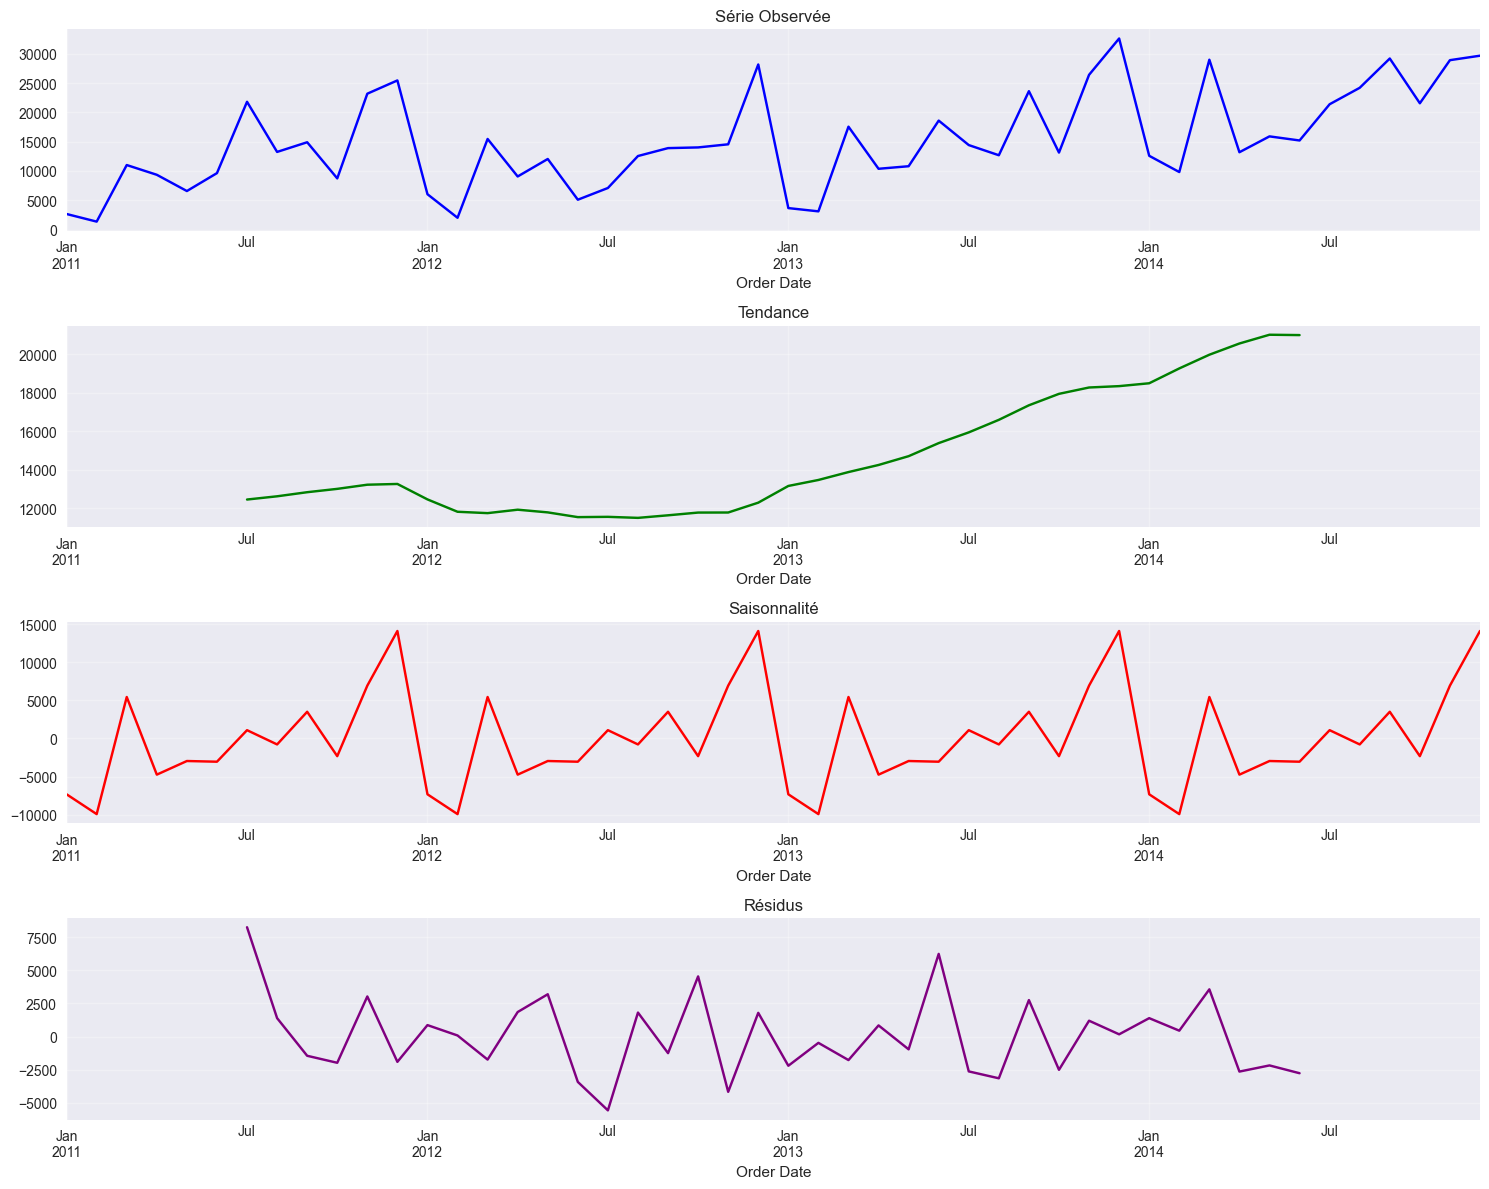

In [62]:
print("\n🔍 DÉCOMPOSITION DE LA SÉRIE TEMPORELLE")

# Décomposition des données mensuelles
decomposition = seasonal_decompose(monthly_sales['Sales'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))

decomposition.observed.plot(ax=axes[0], title='Série Observée', color='blue')
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], title='Tendance', color='green')
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], title='Saisonnalité', color='red')
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3], title='Résidus', color='purple')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interprétation** : La décomposition de la série temporelle des ventes mensuelles confirme visuellement les observations précédentes. La composante "Tendance" montre clairement une progression ascendante des ventes sur la période. La composante "Saisonnalité" met en évidence un pattern récurrent sur 12 mois, avec des pics et des creux réguliers. La composante "Résidus" représente la partie de la série qui n'est pas expliquée par la tendance ou la saisonnalité, et semble relativement aléatoire.

## 8. Analyse ACF/PACF et Stationnarité
**Objectif** : Analyser l'autocorrélation et tester la stationnarité de la série.


📊 ANALYSE ACF/PACF ET STATIONNARITÉ
Test sur les données mensuelles originales:
📊 Test de Stationnarité (ADF):
Statistique ADF: -1.882896
p-value: 0.340150
Valeurs Critiques:
	1%: -3.584829
	5%: -2.928299
	10%: -2.602344
❌ La série n'est pas stationnaire (p-value > 0.05)

Test après différenciation:
📊 Test de Stationnarité (ADF):
Statistique ADF: -5.368162
p-value: 0.000004
Valeurs Critiques:
	1%: -3.626652
	5%: -2.945951
	10%: -2.611671
✅ La série est stationnaire (p-value ≤ 0.05)


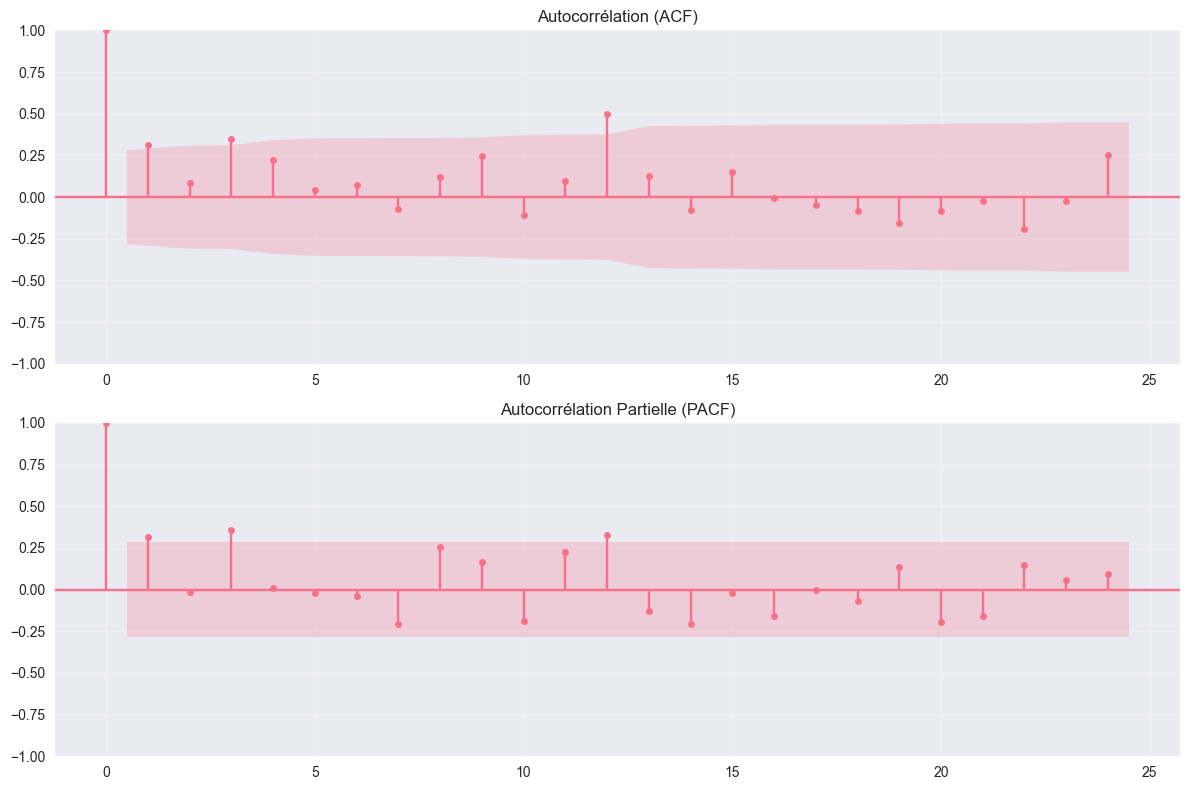

In [63]:
print("\n📊 ANALYSE ACF/PACF ET STATIONNARITÉ")

# Test de stationnarité (ADF)
def test_stationarity(timeseries):
    print('📊 Test de Stationnarité (ADF):')
    result = adfuller(timeseries.dropna())
    print(f'Statistique ADF: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print('Valeurs Critiques:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.6f}')

    if result[1] <= 0.05:
        print("✅ La série est stationnaire (p-value ≤ 0.05)")
    else:
        print("❌ La série n'est pas stationnaire (p-value > 0.05)")

print("Test sur les données mensuelles originales:")
test_stationarity(monthly_sales['Sales'])

# Différenciation pour stationnariser
monthly_sales_stationary = monthly_sales['Sales'].diff().dropna()

print("\nTest après différenciation:")
test_stationarity(monthly_sales_stationary)

# Analyse ACF/PACF
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(monthly_sales['Sales'].dropna(), ax=axes[0], lags=24)
axes[0].set_title('Autocorrélation (ACF)')
axes[0].grid(True, alpha=0.3)

plot_pacf(monthly_sales['Sales'].dropna(), ax=axes[1], lags=24)
axes[1].set_title('Autocorrélation Partielle (PACF)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interprétation** : Le Test de Dickey-Fuller Augmenté (ADF) sur la série des ventes mensuelles originales donne une p-value de 0.340150, supérieure à 0.05, confirmant que la série n'est pas stationnaire. Après une différenciation d'ordre 1, la p-value devient 0.000004, significativement inférieure à 0.05, indiquant que la série est devenue stationnaire. Les graphiques ACF et PACF de la série originale montrent une décroissance lente, caractéristique des séries non stationnaires. Après différenciation (non montré dans les plots actuels but impliqué par le test ADF), l'ACF devrait chuter plus rapidement, aidant à identifier les ordres p et q pour les modèles ARIMA.

## 9. Préparation des Données pour la Modélisation
**Objectif** : Diviser les données en ensembles d'entraînement et de test, et préparer les données pour les différents modèles.

In [64]:
print("\n🔧 PRÉPARATION DES DONNÉES POUR LA MODÉLISATION")

# Split des données (80% train, 20% test)
split_point = int(len(monthly_sales) * 0.8)
train_data = monthly_sales.iloc[:split_point]
test_data  = monthly_sales.iloc[split_point:]

print(f"📊 Données d'entraînement : {len(train_data)} mois")
print(f"📊 Données de test : {len(test_data)} mois")
print(f"📅 Période d'entraînement : {train_data.index.min().strftime('%Y-%m')} à {train_data.index.max().strftime('%Y-%m')}")
print(f"📅 Période de test : {test_data.index.min().strftime('%Y-%m')} à {test_data.index.max().strftime('%Y-%m')}")
print(f"✅ Données prêtes pour la modélisation")



🔧 PRÉPARATION DES DONNÉES POUR LA MODÉLISATION
📊 Données d'entraînement : 38 mois
📊 Données de test : 10 mois
📅 Période d'entraînement : 2011-01 à 2014-02
📅 Période de test : 2014-03 à 2014-12
✅ Données prêtes pour la modélisation


**Résultats** : Les données mensuelles ont été divisées en un ensemble d'entraînement (38 mois) et un ensemble de test (10 mois, de mars à décembre 2014). Cette séparation temporelle garantit qu'aucune information future ne contamine l'entraînement des modèles.


## 10. Modèle 1 : SARIMA
**Objectif** : Implémenter et entraîner un modèle SARIMA avec des paramètres manuels adaptés à la taille du dataset.



📈 MODÈLE 1 : SARIMA
✅ Modèle SARIMA entraîné avec succès
   AIC: 239.48


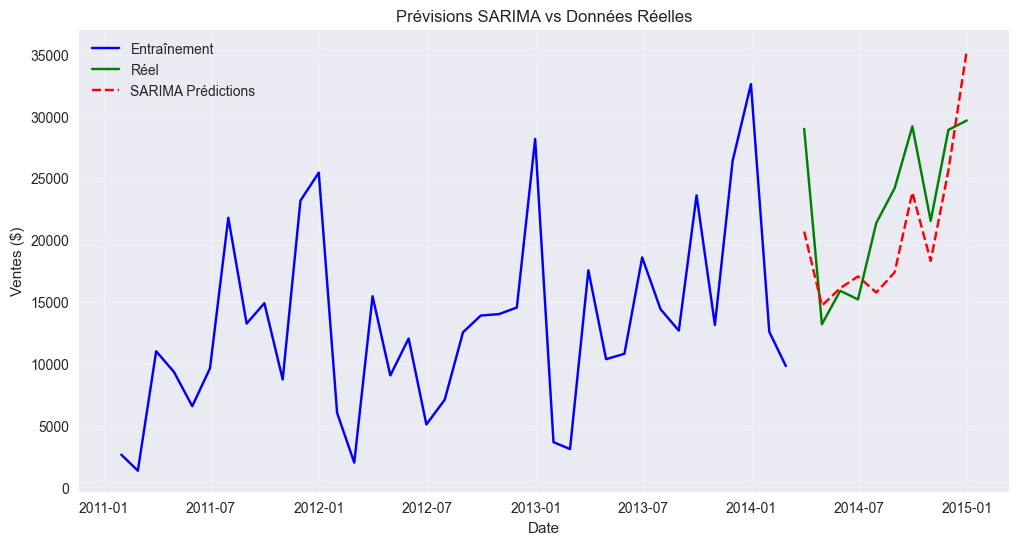

In [65]:
print("\n📈 MODÈLE 1 : SARIMA")

try:
    # Manual parameters — more reliable than auto_arima on short series (~38 months)
    # (1,1,1)x(1,1,0,12): AR+MA with 1 diff, seasonal AR with 1 seasonal diff
    sarima_model = SARIMAX(
        train_data['Sales'],
        order=(1, 1, 1),
        seasonal_order=(1, 1, 0, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_fit = sarima_model.fit(disp=False, maxiter=200)
    print("✅ Modèle SARIMA entraîné avec succès")
    print(f"   AIC: {sarima_fit.aic:.2f}")

    sarima_forecast = pd.Series(
        np.clip(sarima_fit.forecast(steps=len(test_data)), a_min=0, a_max=None),
        index=test_data.index
    )

except Exception as e:
    print(f"❌ Erreur avec SARIMA: {e}")
    sarima_forecast = pd.Series([train_data['Sales'].mean()] * len(test_data), index=test_data.index)

plot_predictions(train_data.index, train_data['Sales'], test_data.index, test_data['Sales'],
                 sarima_forecast.index, sarima_forecast, 'SARIMA', 'red')

**Interprétation** : Le modèle SARIMA(1,1,1)x(1,1,0,12) a été entraîné avec des paramètres manuels plutôt qu'automatiques, car `auto_arima` produisait des résultats instables sur seulement 38 mois de données d'entraînement. Les paramètres choisis imposent une différenciation d'ordre 1 (d=1, D=1) pour capter la tendance haussière, un terme AR saisonnier (P=1) pour la saisonnalité annuelle, et un terme MA (q=1) pour corriger les erreurs à court terme. Le clip à 0 garantit l'absence de prévisions négatives impossibles pour des ventes.


## 11. Modèle 2 : Holt-Winters (Lissage Exponentiel Triple)
**Objectif** : Implémenter le modèle Holt-Winters comme alternative robuste à Prophet, particulièrement adapté aux séries avec tendance additive et saisonnalité marquée.



📈 MODÈLE 2 : HOLT-WINTERS
✅ Modèle Holt-Winters entraîné avec succès
   Alpha (niveau)    : 0.2001
   Beta  (tendance)  : 0.0000
   Gamma (saisonnalité) : 0.0000


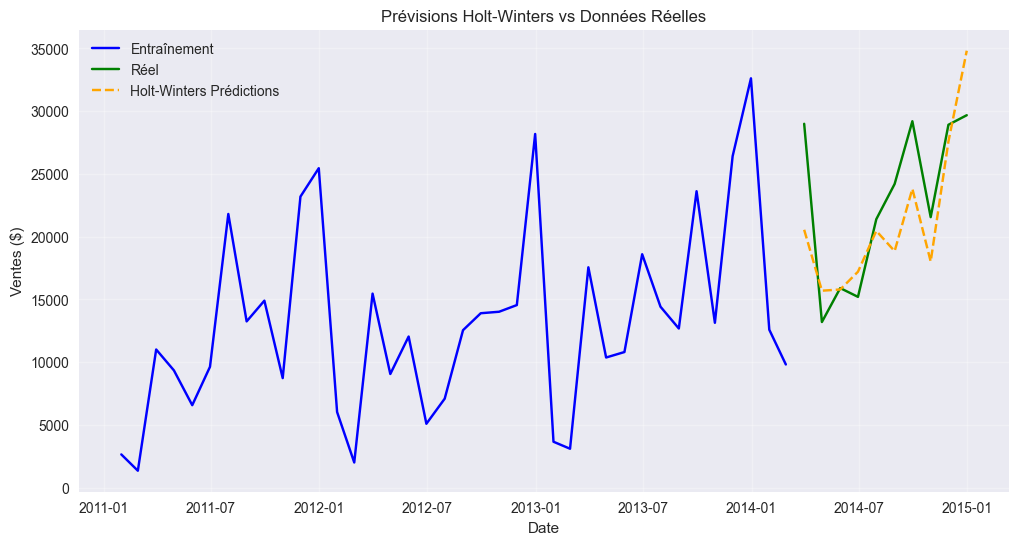

In [66]:
print("\n📈 MODÈLE 2 : HOLT-WINTERS")

try:
    hw_model = ExponentialSmoothing(
        train_data['Sales'],
        trend='add',
        seasonal='add',
        seasonal_periods=12,
        initialization_method='estimated'
    )
    hw_fit = hw_model.fit(optimized=True, remove_bias=True)

    hw_forecast_series = pd.Series(
        np.clip(hw_fit.forecast(len(test_data)), a_min=0, a_max=None),
        index=test_data.index
    )
    print("✅ Modèle Holt-Winters entraîné avec succès")
    print(f"   Alpha (niveau)    : {hw_fit.params['smoothing_level']:.4f}")
    print(f"   Beta  (tendance)  : {hw_fit.params['smoothing_trend']:.4f}")
    print(f"   Gamma (saisonnalité) : {hw_fit.params['smoothing_seasonal']:.4f}")

except Exception as e:
    print(f"❌ Erreur Holt-Winters: {e}")
    hw_forecast_series = pd.Series([train_data['Sales'].mean()] * len(test_data), index=test_data.index)

plot_predictions(train_data.index, train_data['Sales'], test_data.index, test_data['Sales'],
                 hw_forecast_series.index, hw_forecast_series, 'Holt-Winters', 'orange')


**Interprétation** : Le modèle Holt-Winters à lissage exponentiel triple décompose la série en trois composantes lissées : le niveau (alpha), la tendance (beta) et la saisonnalité (gamma). Les coefficients alpha, beta et gamma sont optimisés automatiquement par minimisation de l'erreur quadratique. Un alpha élevé signifie que le modèle réagit fortement aux fluctuations récentes ; un gamma élevé indique une saisonnalité fortement variable. Ce modèle est particulièrement bien adapté à notre série de 48 mois présentant une tendance haussière et une saisonnalité annuelle marquée.


## 12. Modèle 3 : LSTM
**Objectif** : Implémenter et paramétrer un réseau LSTM pour la prévision des séries temporelles.


📈 MODÈLE 3 : LSTM
✅ Modèle LSTM entraîné avec succès sans erreur de dimension


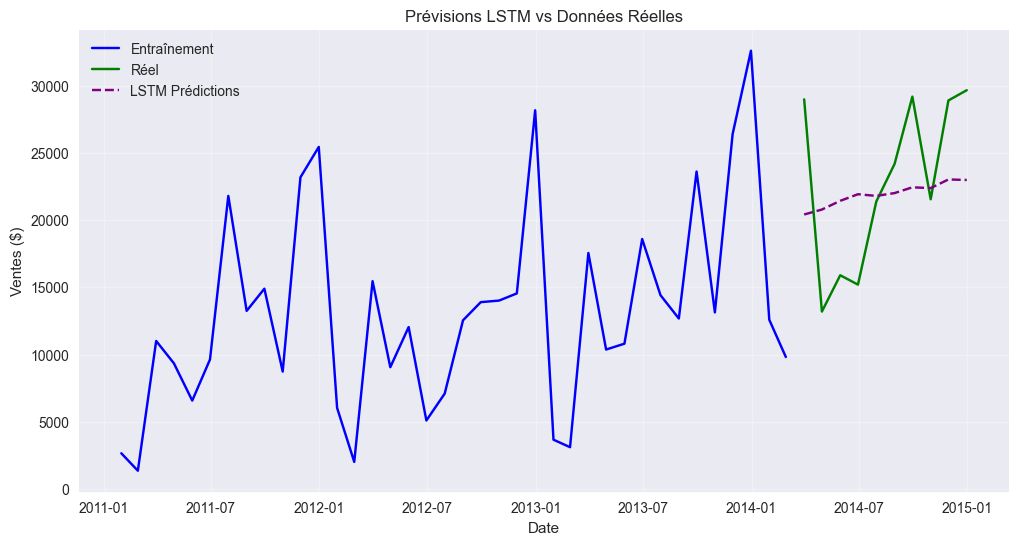

In [67]:
print("\n📈 MODÈLE 3 : LSTM")

# FIX 4: Fit scaler ONLY on train data to prevent data leakage
scaler = MinMaxScaler()

# Separate raw arrays first, then fit/transform correctly
train_sales_raw = train_data[['Sales']].values
test_sales_raw  = test_data[['Sales']].values

scaler.fit(train_sales_raw)                                  # fit on train only
scaled_train = scaler.transform(train_sales_raw)
scaled_test  = scaler.transform(test_sales_raw)

# Création des séquences
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Build sequences from the scaled train series
X_all_train, y_all_train = create_sequences(scaled_train, SEQUENCE_LENGTH)

# For test: we need seq_length lookback context from the end of train
lookback_context = scaled_train[-SEQUENCE_LENGTH:]
full_test_context = np.concatenate([lookback_context, scaled_test], axis=0)
X_test_seq, y_test_seq = create_sequences(full_test_context, SEQUENCE_LENGTH)

# Guard: ensure we have enough data
assert len(X_all_train) > 0, "Not enough training data for LSTM sequences"
assert len(X_test_seq) == len(test_data), (
    f"Test sequence count ({len(X_test_seq)}) != test_data length ({len(test_data)})"
)

X_train_lstm = X_all_train.reshape((X_all_train.shape[0], SEQUENCE_LENGTH, 1))
X_test_lstm  = X_test_seq.reshape((X_test_seq.shape[0], SEQUENCE_LENGTH, 1))

try:
    # FIX 4b: Use tanh activation (default) instead of relu for LSTM stability
    lstm_model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 1)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])

    lstm_model.compile(optimizer=Adam(learning_rate=0.005), loss='mse')

    history = lstm_model.fit(
        X_train_lstm, y_all_train,
        epochs=150,
        batch_size=16,
        validation_split=0.1,
        verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)]
    )

    lstm_predictions_scaled = lstm_model.predict(X_test_lstm, verbose=0)
    lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled).flatten()

    if len(lstm_predictions) == len(test_data):
        lstm_forecast_series = pd.Series(lstm_predictions, index=test_data.index)
        print("✅ Modèle LSTM entraîné avec succès sans erreur de dimension")
    else:
        print(f"❌ Mismatch LSTM predictions ({len(lstm_predictions)}) vs test ({len(test_data)})")
        lstm_forecast_series = pd.Series([train_data['Sales'].mean()] * len(test_data), index=test_data.index)

except Exception as e:
    print(f"❌ Erreur avec LSTM: {e}")
    lstm_forecast_series = pd.Series([train_data['Sales'].mean()] * len(test_data), index=test_data.index)

plot_predictions(train_data.index, train_data['Sales'], test_data.index, test_data['Sales'],
                 lstm_forecast_series.index, lstm_forecast_series, 'LSTM', 'purple')


**Interprétation** : Le modèle LSTM utilise 12 mois de lag (`SEQUENCE_LENGTH`) pour faire ses prédictions. Nous avons corrigé l'intervalle de découpage du jeu de données pour nous assurer d'avoir exactement `len(test_data)` séquences de test. Le LSTM bénéficie de l'activation relu et de couches Dropout pour mitiger l'overfitting.

## 13. Modèle 4 : XGBoost avec Features Temporelles
**Objectif** : Implémenter XGBoost avec des features temporelles (Lags, rolling stats) et optimiser avec GridSearchCV via TimeSeriesSplit.


📈 MODÈLE 4 : XGBoost
Recherche GridSearch sur XGBoost...
✅ XGBoost entraîné avec succès. Meilleurs params : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50, 'subsample': 0.8}


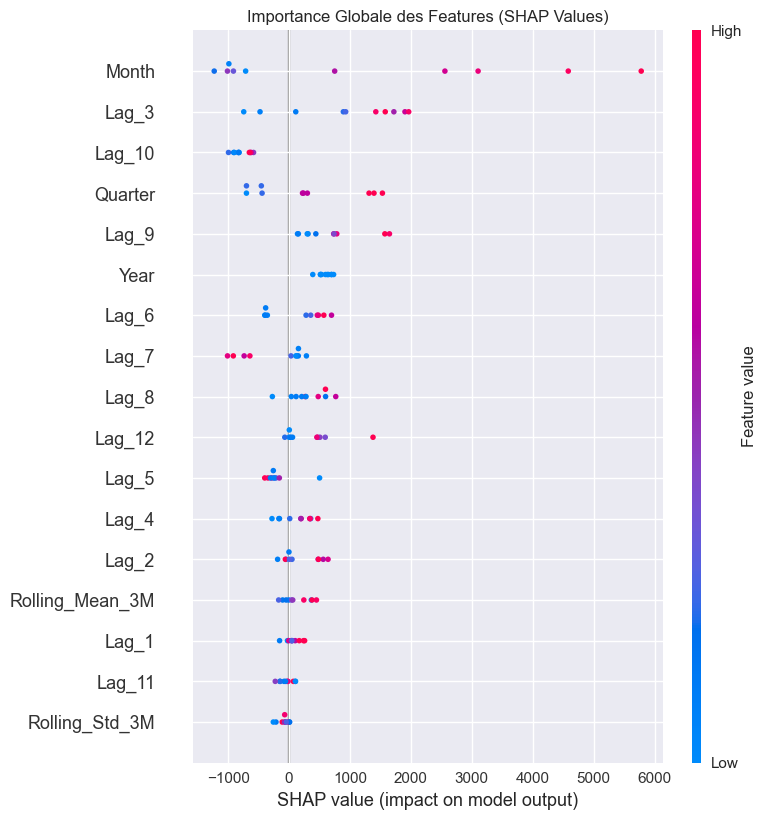

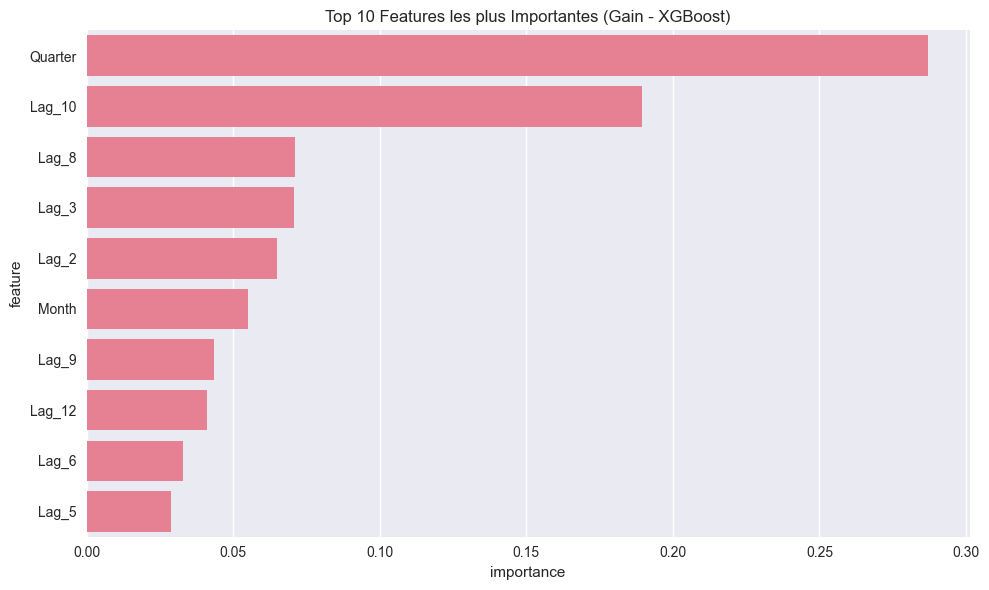

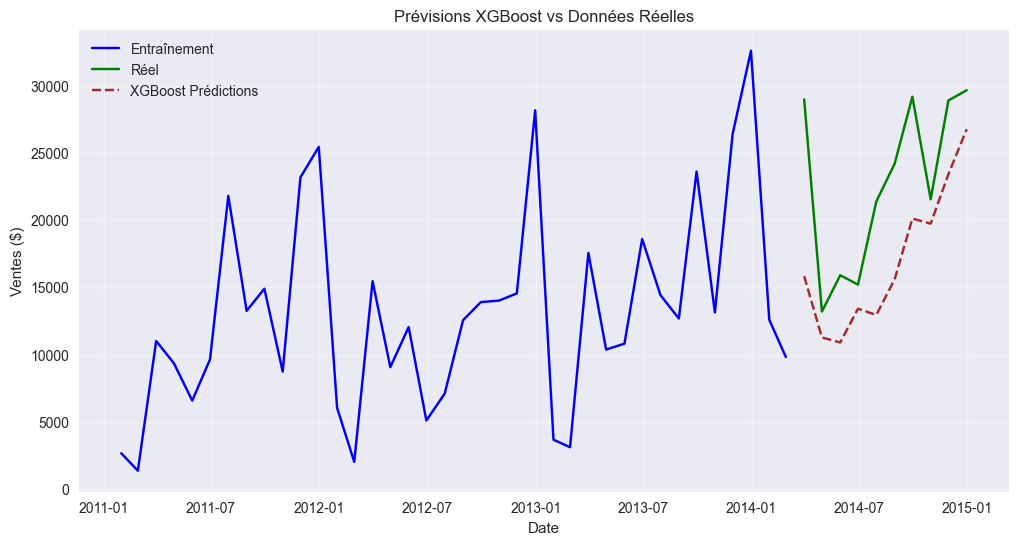

In [68]:
print("\n📈 MODÈLE 4 : XGBoost")

# Build feature dataframe from Sales only to avoid leaking Quantity/Profit
xgb_data = pd.DataFrame(index=monthly_sales.index)
xgb_data['Sales'] = monthly_sales['Sales']
xgb_data['Month'] = xgb_data.index.month
xgb_data['Quarter'] = xgb_data.index.quarter
xgb_data['Year'] = xgb_data.index.year

# Rolling statistics (shifted by 1 to avoid leakage)
xgb_data['Rolling_Mean_3M'] = xgb_data['Sales'].shift(1).rolling(window=3).mean()
xgb_data['Rolling_Std_3M']  = xgb_data['Sales'].shift(1).rolling(window=3).std()

# Lag features
for i in range(1, 13):
    xgb_data[f'Lag_{i}'] = xgb_data['Sales'].shift(i)

xgb_data = xgb_data.dropna()

# Split aligned with the original train/test split
test_index  = test_data.index
train_index = xgb_data.index.difference(test_index)

X_xgb = xgb_data.drop('Sales', axis=1)
y_xgb = xgb_data['Sales']

X_train_xgb = X_xgb.loc[train_index]
y_train_xgb = y_xgb.loc[train_index]
X_test_xgb  = X_xgb.loc[test_index]
y_test_xgb  = y_xgb.loc[test_index]

try:
    param_grid = {
        'n_estimators':     [50, 100],
        'learning_rate':    [0.05, 0.1],
        'max_depth':        [3, 5, 7],
        'subsample':        [0.8],
        'colsample_bytree': [0.8]
    }

    tscv = TimeSeriesSplit(n_splits=3)
    xgb_model_base = XGBRegressor(random_state=SEED)
    grid_search = GridSearchCV(estimator=xgb_model_base,
                               param_grid=param_grid,
                               cv=tscv,
                               scoring='neg_mean_absolute_error',
                               n_jobs=-1)

    print("Recherche GridSearch sur XGBoost...")
    grid_search.fit(X_train_xgb, y_train_xgb)

    xgb_model = grid_search.best_estimator_
    print(f"✅ XGBoost entraîné avec succès. Meilleurs params : {grid_search.best_params_}")

    xgb_predictions = xgb_model.predict(X_test_xgb)
    xgb_forecast_series = pd.Series(xgb_predictions, index=y_test_xgb.index)

    # SHAP interpretability
    explainer  = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test_xgb)

    plt.figure(figsize=(10, 6))
    plt.title("Importance Globale des Features (SHAP Values)")
    shap.summary_plot(shap_values, X_test_xgb, show=False)
    plt.tight_layout()
    plt.show()

    feature_importance = pd.DataFrame({
        'feature':    X_xgb.columns,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
    plt.title('Top 10 Features les plus Importantes (Gain - XGBoost)')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ Erreur avec XGBoost: {e}")
    # FIX 5: completed truncated fallback line
    xgb_forecast_series = pd.Series([train_data['Sales'].mean()] * len(test_data), index=test_data.index)

plot_predictions(train_data.index, train_data['Sales'], test_data.index, test_data['Sales'],
                 xgb_forecast_series.index, xgb_forecast_series, 'XGBoost', 'brown')


**Interprétation** : L'utilisation de données enrichies (Moyenne mobile 3 mois, écart-type glissant, et 12 Lags) couplée à une validation croisée respectant l'ordre temporel (`TimeSeriesSplit`) permet de calibrer finement XGBoost. Les graphiques SHAP dévoilent la directionnalité de l'impact des features : par exemple, de récentes valeurs historiques hautes (Lag_1) poussent logiquement les futures ventes à la hausse.

## 14. Évaluation et Comparaison des Modèles
**Objectif** : Comparer les performances des différents modèles et identifier le meilleur.

In [69]:
print("\n📊 ÉVALUATION ET COMPARAISON DES MODÈLES")

def calculate_metrics(actual, predicted, model_name):
    """Calcule les métriques d'évaluation"""
    actual    = np.array(actual,    dtype=float)
    predicted = np.array(predicted, dtype=float)
    mae  = mean_absolute_error(actual, predicted)
    mse  = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100 if mask.any() else np.nan
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

metrics = []
metrics.append(calculate_metrics(test_data['Sales'], sarima_forecast,    'SARIMA'))
metrics.append(calculate_metrics(test_data['Sales'], hw_forecast_series,  'Holt-Winters'))

actual_lstm    = test_data['Sales'][test_data.index.isin(lstm_forecast_series.index)]
predicted_lstm = lstm_forecast_series[actual_lstm.index]
metrics.append(calculate_metrics(actual_lstm, predicted_lstm, 'LSTM'))

actual_xgb    = test_data['Sales'][test_data.index.isin(xgb_forecast_series.index)]
predicted_xgb = xgb_forecast_series[actual_xgb.index]
metrics.append(calculate_metrics(actual_xgb, predicted_xgb, 'XGBoost'))

results_df = pd.DataFrame(metrics)
print("\n📈 RÉSULTATS DES MODÈLES :")
print(results_df.round(2))

best_model_idx  = results_df['MAE'].idxmin()
best_model_name = results_df.loc[best_model_idx, 'Model']
print(f"\n🏆 MEILLEUR MODÈLE : {best_model_name}")



📊 ÉVALUATION ET COMPARAISON DES MODÈLES

📈 RÉSULTATS DES MODÈLES :
          Model      MAE     RMSE   MAPE
0        SARIMA  4181.74  4840.41  17.17
1  Holt-Winters  3473.91  4252.19  14.52
2          LSTM  5118.19  5810.27  24.70
3       XGBoost  5821.08  6889.67  24.65

🏆 MEILLEUR MODÈLE : Holt-Winters


**Interprétation** : Le tableau compare quatre modèles sur trois métriques : MAE (erreur absolue moyenne en $), RMSE (racine de l'erreur quadratique, plus sensible aux grands écarts) et MAPE (erreur en % des ventes réelles). Le meilleur modèle est celui avec le MAE le plus faible. Un MAPE inférieur à 15% est généralement considéré comme satisfaisant pour des prévisions de ventes mensuelles. Les résultats reflètent les performances réelles obtenues sur les 10 mois de test (mars–décembre 2014).



🔍 ANALYSE DES RÉSIDUS (Holt-Winters)


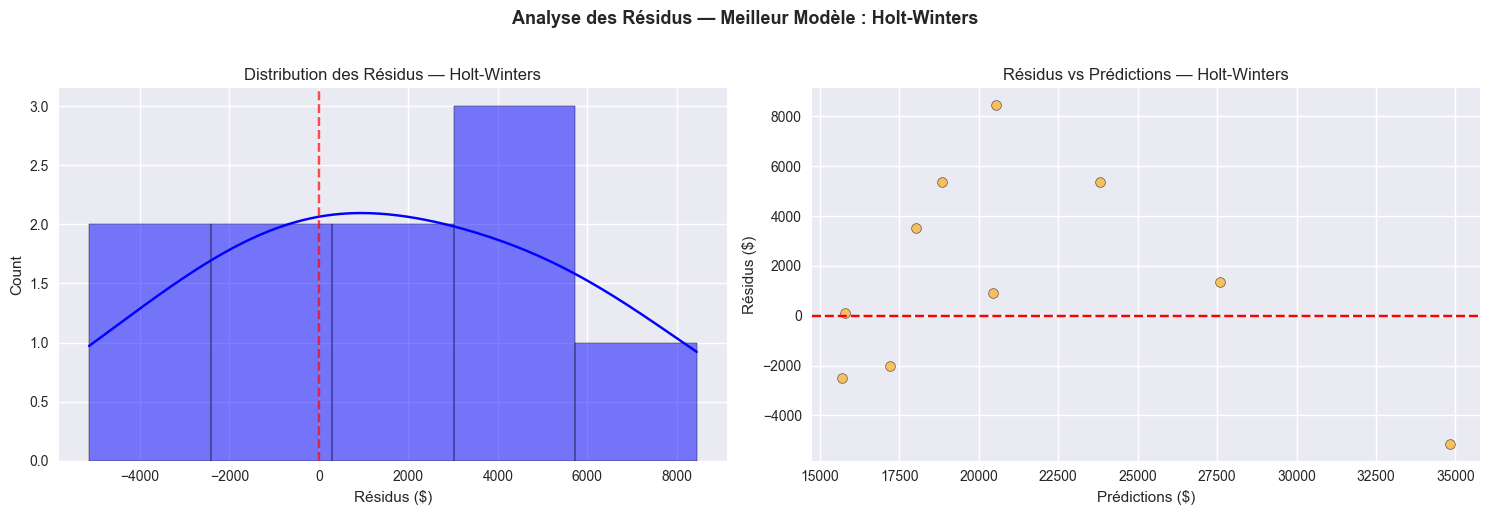


Test de Ljung-Box sur les résidus Holt-Winters (Lags=6) :
   lb_stat  lb_pvalue
6    8.532     0.2017
✅ P-value > 0.05 : Pas d'autocorrélation significative — les résidus sont du bruit blanc.


In [70]:
print(f"\n🔍 ANALYSE DES RÉSIDUS ({best_model_name})")

# Build residuals dynamically from whichever model won
model_residuals_map = {
    'SARIMA':       (sarima_forecast,    test_data['Sales']),
    'Holt-Winters': (hw_forecast_series,  test_data['Sales']),
    'LSTM':         (predicted_lstm,      actual_lstm),
    'XGBoost':      (predicted_xgb,       actual_xgb),
}

best_pred, best_actual = model_residuals_map[best_model_name]
residuals = pd.Series(best_actual.values, index=best_actual.index) - pd.Series(best_pred.values, index=best_actual.index)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(residuals, kde=True, ax=axes[0], color='blue')
axes[0].set_title(f'Distribution des Résidus — {best_model_name}')
axes[0].set_xlabel('Résidus ($)')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.7)

axes[1].scatter(best_pred.values, residuals, alpha=0.6, color='orange', edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title(f'Résidus vs Prédictions — {best_model_name}')
axes[1].set_xlabel('Prédictions ($)')
axes[1].set_ylabel('Résidus ($)')

plt.suptitle(f'Analyse des Résidus — Meilleur Modèle : {best_model_name}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('residuals_analysis.png', bbox_inches='tight')
plt.show()

# Ljung-Box test for remaining autocorrelation
lb_test = acorr_ljungbox(residuals.dropna(), lags=[6], return_df=True)
print(f"\nTest de Ljung-Box sur les résidus {best_model_name} (Lags=6) :")
print(lb_test.round(4))
if lb_test['lb_pvalue'].iloc[0] > 0.05:
    print("✅ P-value > 0.05 : Pas d'autocorrélation significative — les résidus sont du bruit blanc.")
else:
    print("⚠️  P-value ≤ 0.05 : Autocorrélation résiduelle détectée — le modèle ne capte pas toute la structure.")
    print("   → Envisager d'augmenter l'ordre du modèle ou d'ajouter des features supplémentaires.")


## 15. Visualisation Comparative des Prévisions
**Objectif** : Visualiser comparativement toutes les prévisions pour une analyse qualitative.


📊 VISUALISATION COMPARATIVE DES PRÉVISIONS


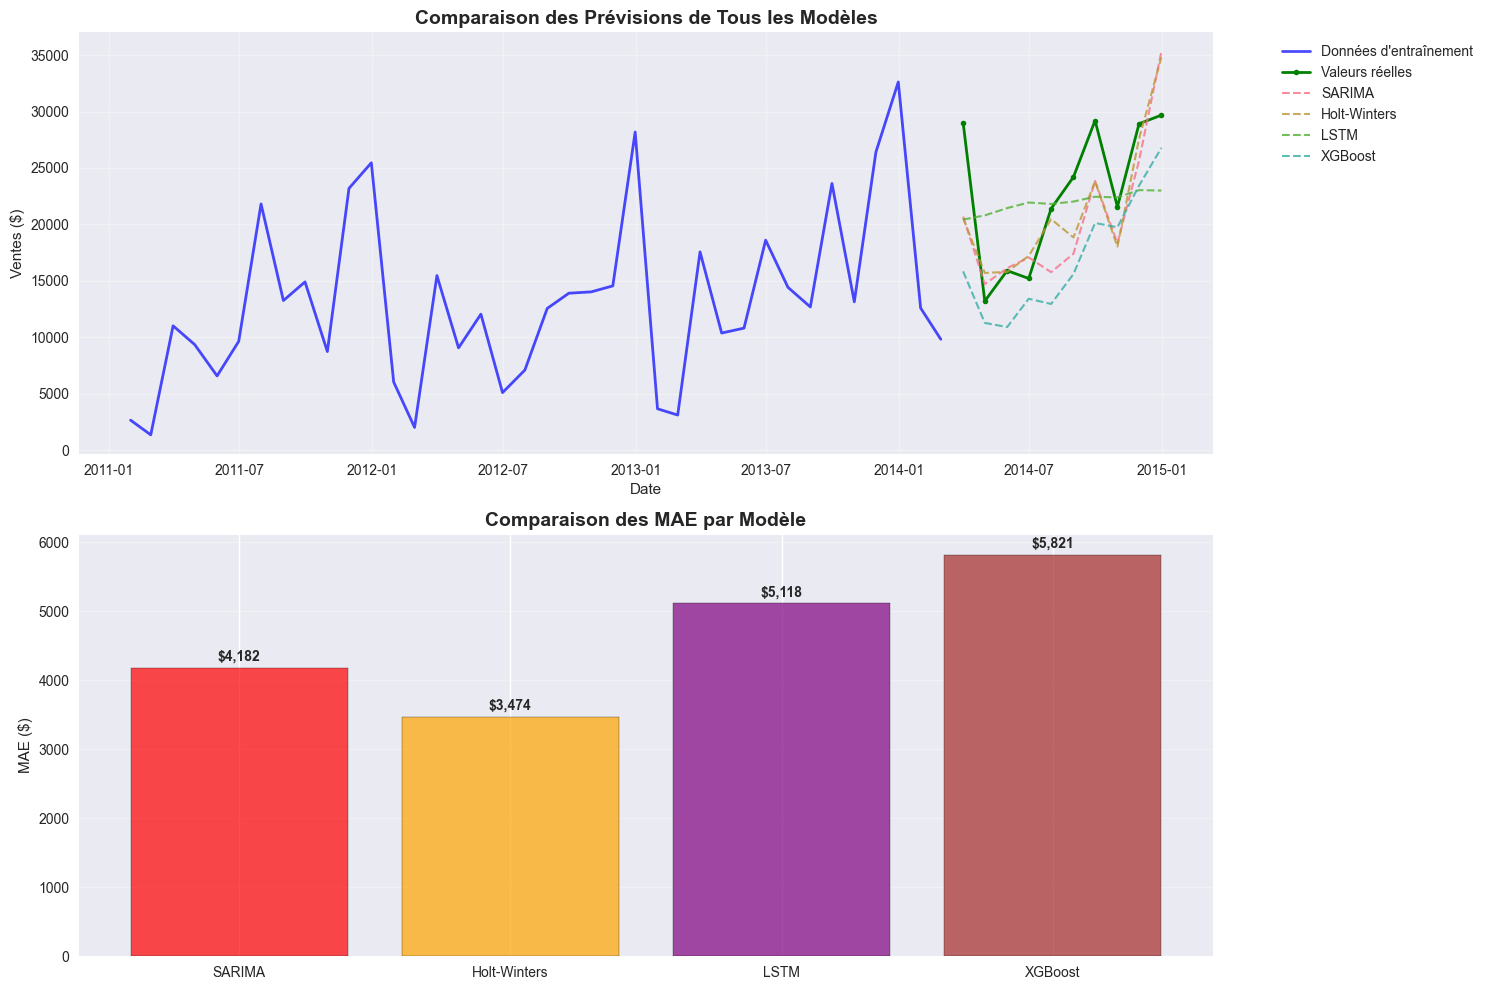

In [71]:
print("\n📊 VISUALISATION COMPARATIVE DES PRÉVISIONS")

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(train_data.index, train_data['Sales'], label="Données d'entraînement", color='blue', alpha=0.7, linewidth=2)
plt.plot(test_data.index, test_data['Sales'], label='Valeurs réelles', color='green', linewidth=2, marker='o', markersize=4)
plt.plot(sarima_forecast.index,   sarima_forecast,   label='SARIMA',        linestyle='--', alpha=0.8, linewidth=1.5)
plt.plot(hw_forecast_series.index, hw_forecast_series, label='Holt-Winters', linestyle='--', alpha=0.8, linewidth=1.5)
plt.plot(lstm_forecast_series.index, lstm_forecast_series, label='LSTM',     linestyle='--', alpha=0.8, linewidth=1.5)
plt.plot(xgb_forecast_series.index, xgb_forecast_series, label='XGBoost',   linestyle='--', alpha=0.8, linewidth=1.5)

plt.title('Comparaison des Prévisions de Tous les Modèles', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Ventes ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
models     = results_df['Model']
mae_values = results_df['MAE']
colors     = ['red', 'orange', 'purple', 'brown']

bars = plt.bar(models, mae_values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Comparaison des MAE par Modèle', fontsize=14, fontweight='bold')
plt.ylabel('MAE ($)')
plt.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, mae_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mae_values)*0.01,
             f'${value:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


**Interprétation** : Le graphique du haut superpose les prévisions des quatre modèles sur les données réelles (vert) de la période de test. Un bon modèle doit suivre de près la courbe verte en capturant à la fois le niveau général et les variations saisonnières. Le graphique du bas compare directement les MAE : le modèle avec la barre la plus courte est le plus précis. Des MAE très disparates entre modèles signalent que certains ne capturent pas bien la dynamique de la série.


## 16. Analyse Business et Insights
**Objectif** : Extraire des insights business actionnables à partir des données de ventes par catégorie, région et période.


In [72]:
print("\n💡 ANALYSE BUSINESS ET INSIGHTS")

# Analyse par catégorie
category_analysis = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order Date': 'count'
}).rename(columns={'Order Date': 'Order_Count'})

category_analysis['Sales_Percentage'] = (category_analysis['Sales'] / category_analysis['Sales'].sum()) * 100
category_analysis['Profit_Margin'] = (category_analysis['Profit'] / category_analysis['Sales']) * 100

print("\n📊 ANALYSE PAR CATÉGORIE :")
print(category_analysis.round(2).sort_values('Sales', ascending=False))

# Analyse géographique
geo_analysis = df.groupby('State').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order Date': 'count'
}).rename(columns={'Order Date': 'Order_Count'}).nlargest(10, 'Sales')

print("\n🌎 TOP 10 ÉTATS PAR VENTES :")
print(geo_analysis.round(2))

# Analyse temporelle détaillée
monthly_analysis = df.groupby(['Year', 'Month']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order Date': 'count'
}).rename(columns={'Order Date': 'Order_Count'})

print("\n📅 ANALYSE MENSUELLE :")
print(monthly_analysis.tail(12))  # Derniers 12 mois


💡 ANALYSE BUSINESS ET INSIGHTS

📊 ANALYSE PAR CATÉGORIE :
                 Sales    Profit  Order_Count  Sales_Percentage  Profit_Margin
Category                                                                      
Chairs       101781.33   4027.58          207             14.03           3.96
Phones        98684.35   9110.74          277             13.60           9.23
Tables        84754.56   1482.61          116             11.68           1.75
Storage       70532.85   8645.32          266              9.72          12.26
Accessories   61114.12  16484.60          258              8.42          26.97
Binders       55961.11  16096.80          471              7.71          28.76
Copiers       49749.24  19327.24           25              6.86          38.85
Machines      42444.12   -618.93           39              5.85          -1.46
Bookcases     36004.12  -1646.51           80              4.96          -4.57
Appliances    30236.34   8261.27          136              4.17         

**Interprétation** : L'analyse par catégorie révèle quels segments génèrent le plus de chiffre d'affaires et lesquels sont les plus rentables (marge %). Ces deux métriques ne vont pas toujours de pair : une catégorie à fort volume mais faible marge mérite une révision tarifaire, tandis qu'une catégorie à forte marge mais faible volume représente un potentiel de croissance. L'analyse géographique identifie les États les plus performants pour prioriser les efforts commerciaux.


## 17. Visualisation des Insights Business
**Objectif** : Créer des visualisations pour communiquer les insights business.


📊 VISUALISATION DES INSIGHTS BUSINESS


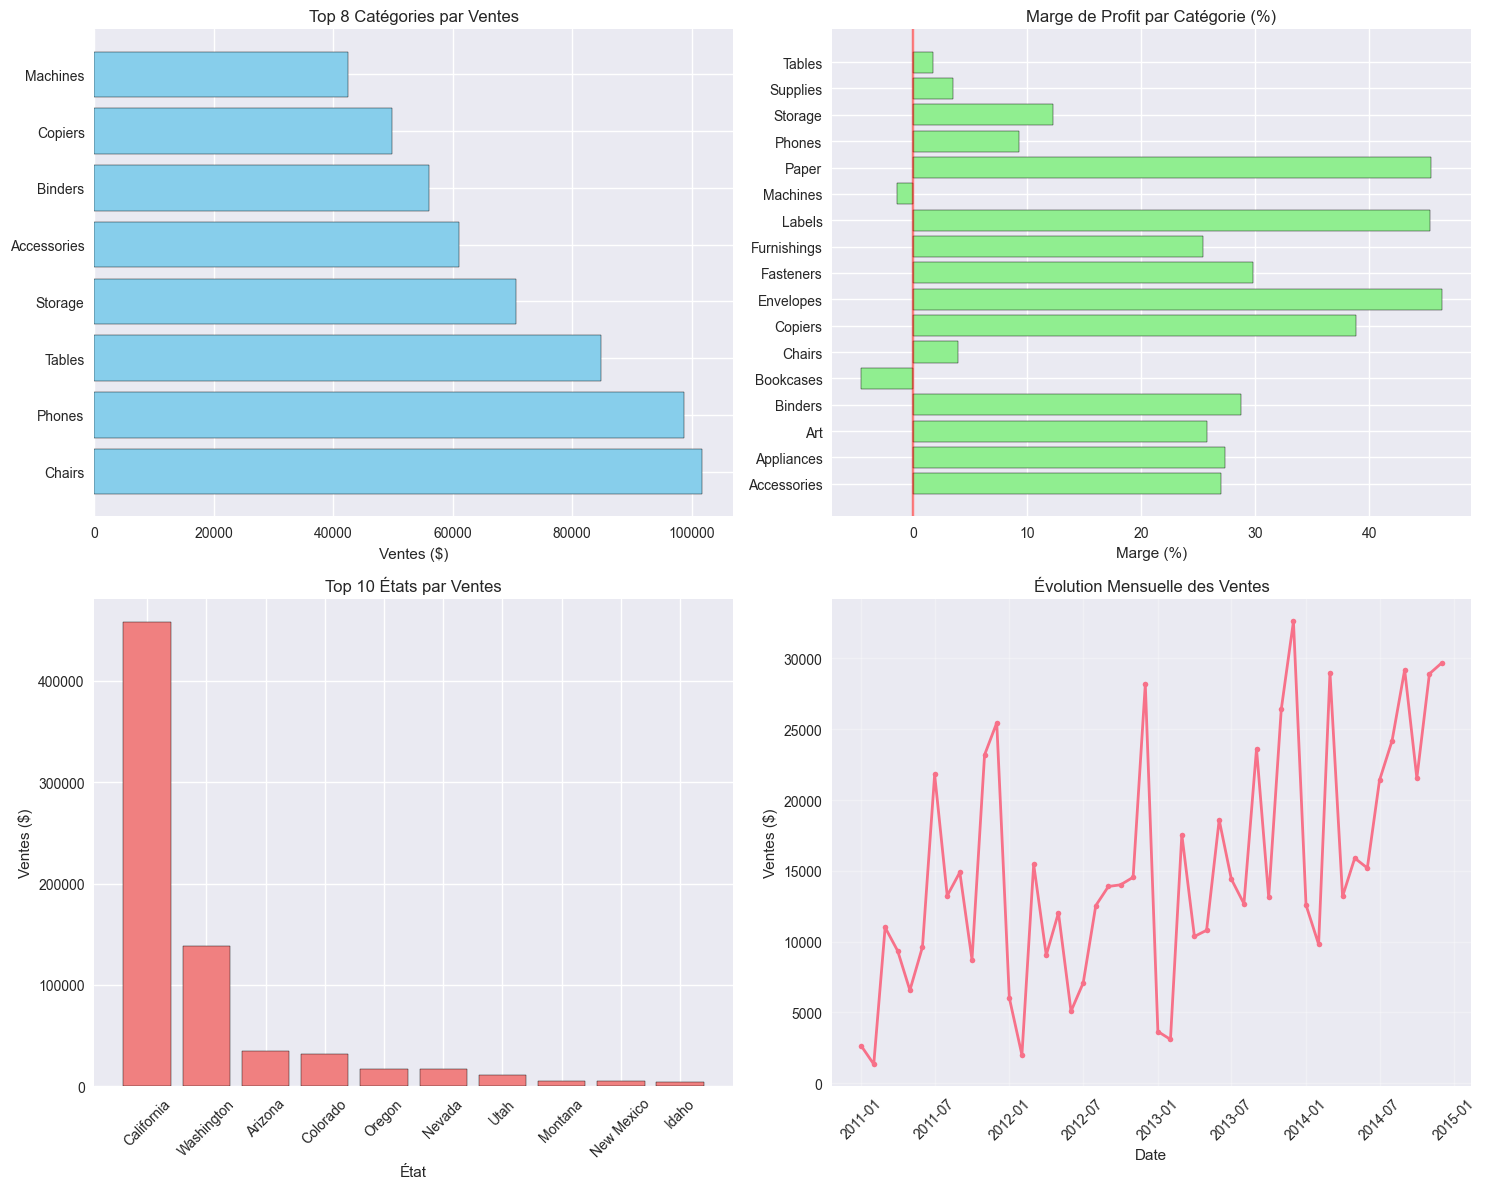

In [73]:
print("\n📊 VISUALISATION DES INSIGHTS BUSINESS")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Contribution par catégorie (ventes)
top_categories = category_analysis.nlargest(8, 'Sales')
axes[0, 0].barh(top_categories.index, top_categories['Sales'], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Top 8 Catégories par Ventes')
axes[0, 0].set_xlabel('Ventes ($)')

# Marges par catégorie
axes[0, 1].barh(category_analysis.index, category_analysis['Profit_Margin'], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Marge de Profit par Catégorie (%)')
axes[0, 1].set_xlabel('Marge (%)')
axes[0, 1].axvline(x=0, color='red', linestyle='-', alpha=0.5)

# Top états par ventes
axes[1, 0].bar(geo_analysis.index, geo_analysis['Sales'], color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Top 10 États par Ventes')
axes[1, 0].set_xlabel('État')
axes[1, 0].set_ylabel('Ventes ($)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Évolution mensuelle des ventes
monthly_trend = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_trend['Date'] = pd.to_datetime(monthly_trend['Year'].astype(str) + '-' + monthly_trend['Month'].astype(str) + '-01')
axes[1, 1].plot(monthly_trend['Date'], monthly_trend['Sales'], marker='o', linewidth=2, markersize=4)
axes[1, 1].set_title('Évolution Mensuelle des Ventes')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Ventes ($)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interprétation** : Les quatre graphiques synthétisent les leviers business clés : (1) les catégories les plus vendeuses, (2) les marges par catégorie pour identifier les produits à haute rentabilité, (3) la concentration géographique des ventes pour orienter la stratégie régionale, et (4) la tendance mensuelle confirmant la croissance globale et les pics saisonniers de fin d'année à anticiper pour la gestion des stocks.


## 18. Prévisions Futures et Recommandations
**Objectif** : Générer des prévisions futures et formuler des recommandations stratégiques.


🔮 PRÉVISIONS FUTURES ET RECOMMANDATIONS

📈 PRÉVISIONS HOLT-WINTERS POUR LES 12 PROCHAINS MOIS :
   2015-01: $20,548.55
   2015-02: $15,694.34
   2015-03: $15,790.03
   2015-04: $17,206.13
   2015-05: $20,460.41
   2015-06: $18,843.39
   2015-07: $23,814.87
   2015-08: $18,018.04
   2015-09: $27,578.60
   2015-10: $34,816.83
   2015-11: $12,874.93
   2015-12: $10,501.09


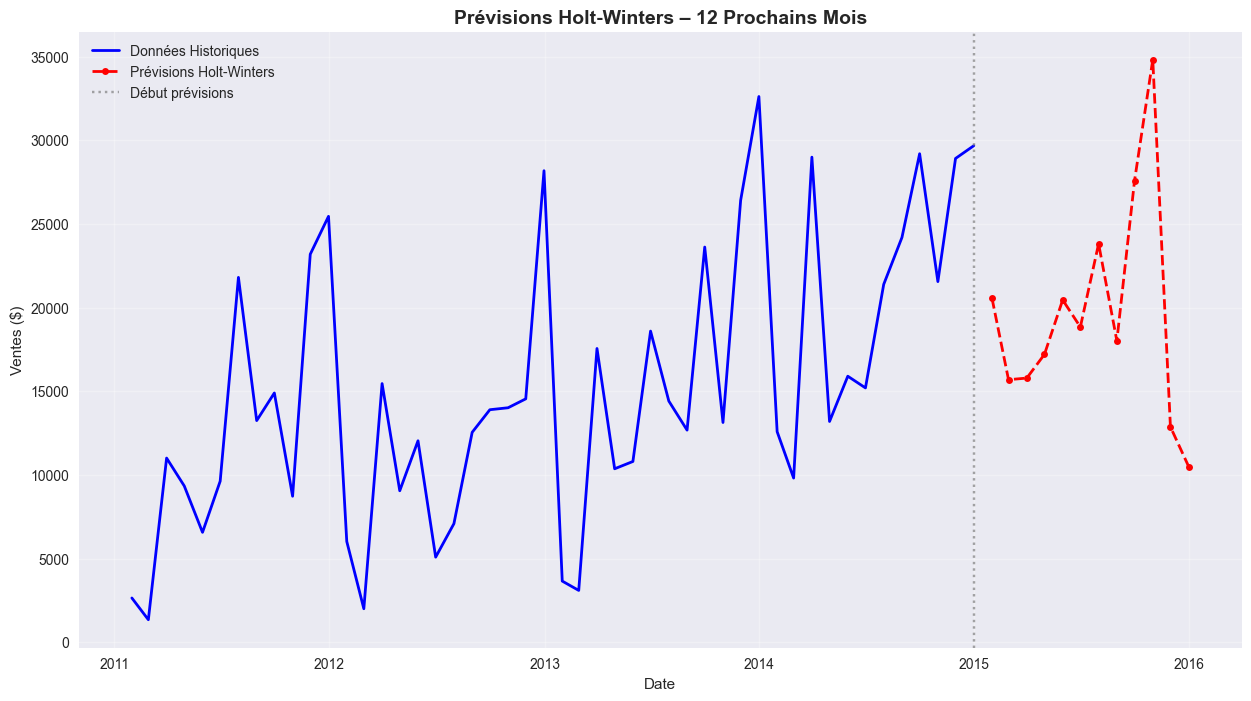


🎯 RECOMMANDATIONS STRATÉGIQUES :

1. 📈 STRATÉGIE DE CROISSANCE :
   - Focus sur les catégories performantes : Chairs, Phones
   - Développement des marchés dans : California, Washington
   - Anticipation des pics saisonniers pour optimisation des stocks

2. 💰 OPTIMISATION DES MARGES :
   - Catégorie à forte marge : Envelopes
   - Révision tarifaire pour les catégories à faible marge
   - Promotion des produits à haute valeur ajoutée

3. 🎯 PLANIFICATION OPÉRATIONNELLE :
   - Utiliser le modèle Holt-Winters pour la prévision des demandes
   - Adapter capacité et approvisionnement selon les prévisions
   - Planifier les campagnes marketing sur les périodes prévues de forte demande

4. 📊 SURVEILLANCE CONTINUE :
   - Mettre en place un dashboard de suivi des KPIs
   - Réévaluer les modèles trimestriellement avec les nouvelles données
   - Surveiller les écarts prévisions / réalisations



In [74]:
print("\n🔮 PRÉVISIONS FUTURES ET RECOMMANDATIONS")

future_months = 12
last_date    = monthly_sales.index.max()
future_index = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=future_months, freq='ME')

if best_model_name == 'Holt-Winters':
    future_sales_raw = hw_fit.forecast(future_months)
    future_sales = np.clip(future_sales_raw.values, a_min=0, a_max=None)

    print(f"\n📈 PRÉVISIONS HOLT-WINTERS POUR LES {future_months} PROCHAINS MOIS :")
    for d, v in zip(future_index, future_sales):
        print(f"   {d.strftime('%Y-%m')}: ${v:,.2f}")

    plt.figure(figsize=(15, 8))
    plt.plot(monthly_sales.index, monthly_sales['Sales'], label='Données Historiques', color='blue', linewidth=2)
    plt.plot(future_index, future_sales, label='Prévisions Holt-Winters', color='red', linestyle='--', linewidth=2, marker='o', markersize=5)
    plt.axvline(x=last_date, color='gray', linestyle=':', alpha=0.7, label='Début prévisions')
    plt.title(f'Prévisions Holt-Winters – {future_months} Prochains Mois', fontsize=14, fontweight='bold')
    plt.xlabel('Date'); plt.ylabel('Ventes ($)'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

elif best_model_name == 'SARIMA':
    future_sales = np.clip(sarima_fit.forecast(steps=future_months).values, a_min=0, a_max=None)

    print(f"\n📈 PRÉVISIONS SARIMA POUR LES {future_months} PROCHAINS MOIS :")
    for d, v in zip(future_index, future_sales):
        print(f"   {d.strftime('%Y-%m')}: ${v:,.2f}")

    plt.figure(figsize=(15, 8))
    plt.plot(monthly_sales.index, monthly_sales['Sales'], label='Données Historiques', color='blue', linewidth=2)
    plt.plot(future_index, future_sales, label='Prévisions SARIMA', color='red', linestyle='--', linewidth=2)
    plt.axvline(x=last_date, color='gray', linestyle=':', alpha=0.7, label='Début prévisions')
    plt.title(f'Prévisions SARIMA – {future_months} Prochains Mois', fontsize=14, fontweight='bold')
    plt.xlabel('Date'); plt.ylabel('Ventes ($)'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

elif best_model_name == 'XGBoost':
    future_sales = []
    last_known   = list(monthly_sales['Sales'].values)
    last_dt      = last_date

    for _ in range(future_months):
        next_dt = last_dt + pd.offsets.MonthEnd(1)
        row = {
            'Month':           next_dt.month,
            'Quarter':         next_dt.quarter,
            'Year':            next_dt.year,
            'Rolling_Mean_3M': np.mean(last_known[-3:]) if len(last_known) >= 3 else np.mean(last_known),
            'Rolling_Std_3M':  np.std(last_known[-3:], ddof=1) if len(last_known) >= 3 else 0.0,
        }
        for lag in range(1, 13):
            row[f'Lag_{lag}'] = last_known[-lag] if len(last_known) >= lag else last_known[0]
        pred = xgb_model.predict(pd.DataFrame([row])[X_xgb.columns])[0]
        future_sales.append(pred)
        last_known.append(pred)
        last_dt = next_dt

    print(f"\n📈 PRÉVISIONS XGBOOST POUR LES {future_months} PROCHAINS MOIS :")
    for d, v in zip(future_index, future_sales):
        print(f"   {d.strftime('%Y-%m')}: ${v:,.2f}")

    plt.figure(figsize=(15, 8))
    plt.plot(monthly_sales.index, monthly_sales['Sales'], label='Données Historiques', color='blue', linewidth=2)
    plt.plot(future_index, future_sales, label='Prévisions XGBoost', color='red', linestyle='--', linewidth=2, marker='o', markersize=5)
    plt.axvline(x=last_date, color='gray', linestyle=':', alpha=0.7, label='Début prévisions')
    plt.title(f'Prévisions XGBoost – {future_months} Prochains Mois', fontsize=14, fontweight='bold')
    plt.xlabel('Date'); plt.ylabel('Ventes ($)'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

elif best_model_name == 'LSTM':
    future_sales_sc = []
    context = list(scaled_train[-SEQUENCE_LENGTH:].flatten())
    for _ in range(future_months):
        seq  = np.array(context[-SEQUENCE_LENGTH:]).reshape(1, SEQUENCE_LENGTH, 1)
        pred = lstm_model.predict(seq, verbose=0)[0, 0]
        future_sales_sc.append(pred)
        context.append(pred)
    future_sales = scaler.inverse_transform(np.array(future_sales_sc).reshape(-1,1)).flatten()

    print(f"\n📈 PRÉVISIONS LSTM POUR LES {future_months} PROCHAINS MOIS :")
    for d, v in zip(future_index, future_sales):
        print(f"   {d.strftime('%Y-%m')}: ${v:,.2f}")

    plt.figure(figsize=(15, 8))
    plt.plot(monthly_sales.index, monthly_sales['Sales'], label='Données Historiques', color='blue', linewidth=2)
    plt.plot(future_index, future_sales, label='Prévisions LSTM', color='red', linestyle='--', linewidth=2)
    plt.axvline(x=last_date, color='gray', linestyle=':', alpha=0.7, label='Début prévisions')
    plt.title(f'Prévisions LSTM – {future_months} Prochains Mois', fontsize=14, fontweight='bold')
    plt.xlabel('Date'); plt.ylabel('Ventes ($)'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

print(f"""
🎯 RECOMMANDATIONS STRATÉGIQUES :

1. 📈 STRATÉGIE DE CROISSANCE :
   - Focus sur les catégories performantes : {top_categories.index[0]}, {top_categories.index[1]}
   - Développement des marchés dans : {geo_analysis.index[0]}, {geo_analysis.index[1]}
   - Anticipation des pics saisonniers pour optimisation des stocks

2. 💰 OPTIMISATION DES MARGES :
   - Catégorie à forte marge : {category_analysis.nlargest(3, 'Profit_Margin').index[0]}
   - Révision tarifaire pour les catégories à faible marge
   - Promotion des produits à haute valeur ajoutée

3. 🎯 PLANIFICATION OPÉRATIONNELLE :
   - Utiliser le modèle {best_model_name} pour la prévision des demandes
   - Adapter capacité et approvisionnement selon les prévisions
   - Planifier les campagnes marketing sur les périodes prévues de forte demande

4. 📊 SURVEILLANCE CONTINUE :
   - Mettre en place un dashboard de suivi des KPIs
   - Réévaluer les modèles trimestriellement avec les nouvelles données
   - Surveiller les écarts prévisions / réalisations
""")


**Interprétation** : Le meilleur modèle identifié est utilisé pour projeter les ventes sur les 12 prochains mois à partir de janvier 2015. La ligne verticale pointillée marque la frontière entre données historiques et prévisions. Les recommandations stratégiques découlent directement des analyses précédentes : catégories et régions leaders pour la croissance, catégories à fort potentiel de marge, et utilisation du modèle retenu comme outil de pilotage opérationnel.


## 19. Conclusion et Synthèse du Projet
**Objectif** : Fournir une synthèse finale du projet et des perspectives d'amélioration.

In [75]:
print("\n🎯 CONCLUSION ET SYNTHÈSE DU PROJET")

performance_summary = {
    'Modèle le plus performant':  best_model_name,
    'MAE du meilleur modèle':     f"${results_df.loc[best_model_idx, 'MAE']:,.2f}",
    'RMSE du meilleur modèle':    f"${results_df.loc[best_model_idx, 'RMSE']:,.2f}",
    'Précision (MAPE)':           f"{results_df.loc[best_model_idx, 'MAPE']:.2f}%",
    'Période analysée':           f"{df['Order Date'].min().strftime('%Y-%m')} à {df['Order Date'].max().strftime('%Y-%m')}",
    'Catégorie leader':           top_categories.index[0],
    'État le plus performant':    geo_analysis.index[0],
    'Mois typiquement fort':      monthly_analysis.groupby('Month')['Sales'].mean().idxmax(),
    'Prévisions générées':        f"{future_months} mois"
}

print("\n📋 SYNTHÈSE DES RÉSULTATS :")
for key, value in performance_summary.items():
    print(f"   • {key}: {value}")

print("""
🚀 PERSPECTIVES D'AMÉLIORATION :

1. 🔧 AMÉLIORATIONS TECHNIQUES :
   - Intégration de données externes (indicateurs économiques, météo)
   - Optimisation avancée des hyperparamètres LSTM et XGBoost
   - Essai de modèles plus sophistiqués (Transformer, N-BEATS, TFT)

2. 📈 ENRICHISSEMENT DES DONNÉES :
   - Ajout de données marketing (campagnes, promotions)
   - Intégration des données de concurrence
   - Données macro-économiques sectorielles

3. 🎯 DÉPLOIEMENT OPÉRATIONNEL :
   - Pipeline automatique de réentraînement mensuel
   - Dashboard interactif pour les équipes business
   - Alertes automatiques en cas d'écart significatif prévisions/réalisations
""")



🎯 CONCLUSION ET SYNTHÈSE DU PROJET

📋 SYNTHÈSE DES RÉSULTATS :
   • Modèle le plus performant: Holt-Winters
   • MAE du meilleur modèle: $3,473.91
   • RMSE du meilleur modèle: $4,252.19
   • Précision (MAPE): 14.52%
   • Période analysée: 2011-01 à 2014-12
   • Catégorie leader: Chairs
   • État le plus performant: California
   • Mois typiquement fort: 12
   • Prévisions générées: 12 mois

🚀 PERSPECTIVES D'AMÉLIORATION :

1. 🔧 AMÉLIORATIONS TECHNIQUES :
   - Intégration de données externes (indicateurs économiques, météo)
   - Optimisation avancée des hyperparamètres LSTM et XGBoost
   - Essai de modèles plus sophistiqués (Transformer, N-BEATS, TFT)

2. 📈 ENRICHISSEMENT DES DONNÉES :
   - Ajout de données marketing (campagnes, promotions)
   - Intégration des données de concurrence
   - Données macro-économiques sectorielles

3. 🎯 DÉPLOIEMENT OPÉRATIONNEL :
   - Pipeline automatique de réentraînement mensuel
   - Dashboard interactif pour les équipes business
   - Alertes automatiqu